In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv('marketing.csv')

In [ ]:
data.shape

(200000, 16)

In [ ]:
data.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [ ]:
data[data.duplicated()]

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date


In [ ]:
data.duplicated().any()

np.False_

In [ ]:
data.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [ ]:
data.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')

In [ ]:
data.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,1/1/2021
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,1/2/2021
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,1/3/2021
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,1/4/2021
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,1/5/2021


In [ ]:
data.dtypes

Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
dtype: object

In [ ]:
data['Acquisition_Cost']=data['Acquisition_Cost'].str.replace('$','')

In [ ]:
data['Acquisition_Cost']=data['Acquisition_Cost'].str.replace(',','')

In [ ]:
data['Acquisition_Cost']=pd.to_numeric(data['Acquisition_Cost'],errors='coerce')

In [ ]:
data.dtypes

Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost    float64
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
dtype: object

In [ ]:
data['Date']=pd.to_datetime(data['Date'],errors='coerce')

In [ ]:
data['Duration']=data['Duration'].str.replace('days','')
data['Duration']=pd.to_numeric(data['Duration'],errors='coerce')

In [ ]:
data[['Gender','Age_group']]=data['Target_Audience'].str.split(' ',expand=True)

In [ ]:
data.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Gender,Age_group
0,1,Innovate Industries,Email,Men 18-24,30,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,Men,18-24
1,2,NexGen Systems,Email,Women 35-44,60,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,Women,35-44
2,3,Alpha Innovations,Influencer,Men 25-34,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,Men,25-34
3,4,DataTech Solutions,Display,All Ages,60,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,All,Ages
4,5,NexGen Systems,Email,Men 25-34,15,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,Men,25-34


In [ ]:
df=data.copy()

In [ ]:
df.drop(columns=['Campaign_ID','Target_Audience'],inplace=True)

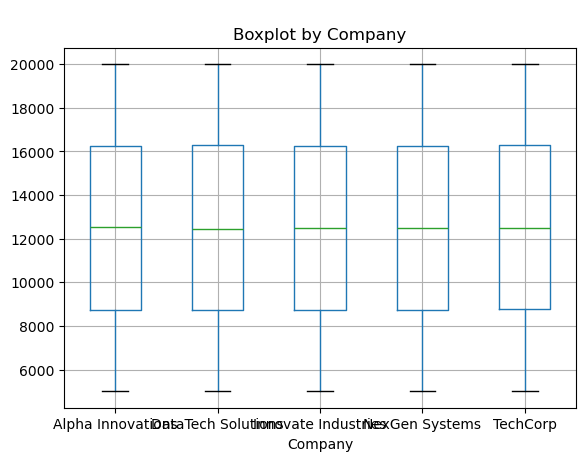

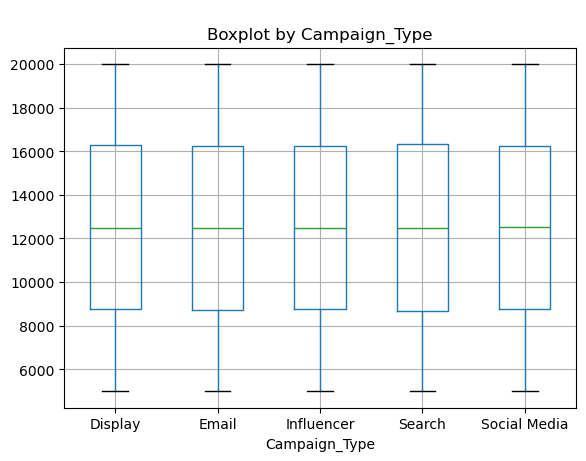

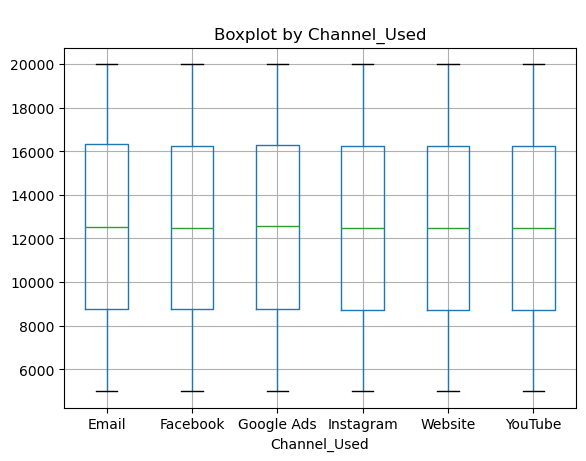

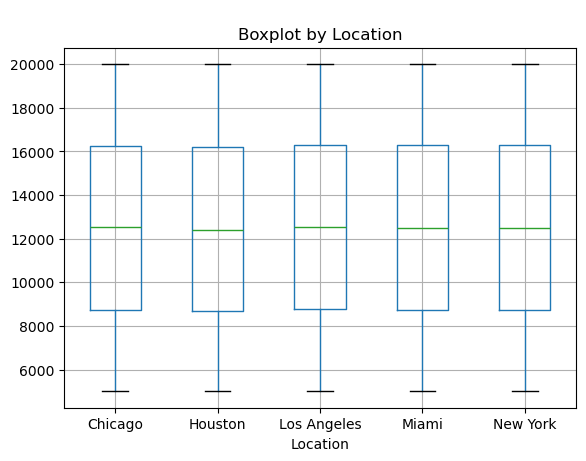

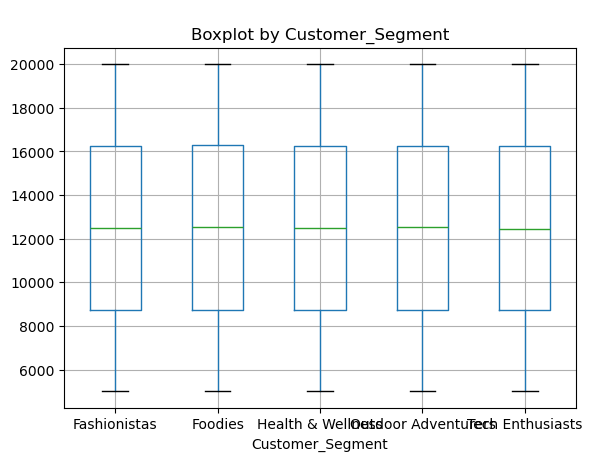

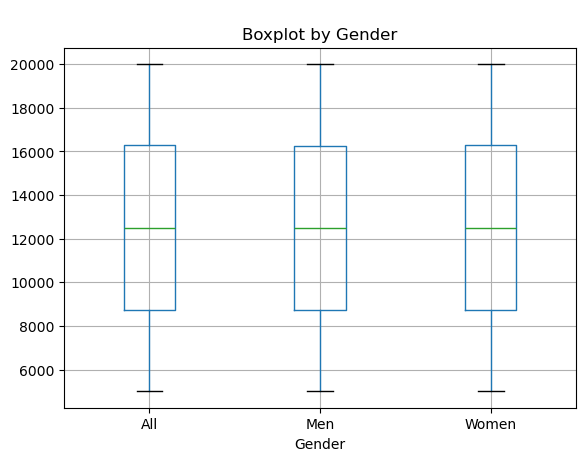

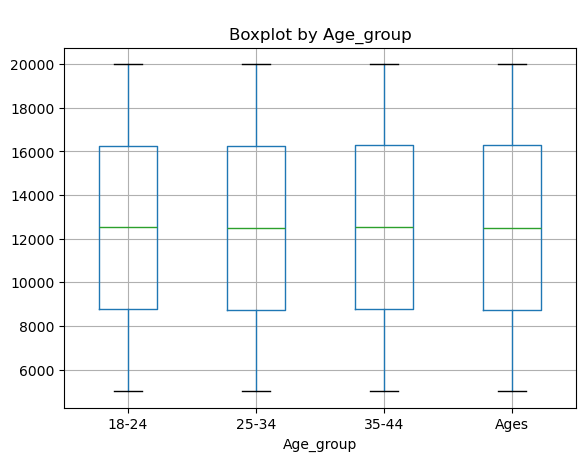

In [ ]:
col=['Company','Campaign_Type','Channel_Used','Location','Customer_Segment','Gender','Age_group']
for i in col:
    df.boxplot('Acquisition_Cost',by=i)
    plt.suptitle(' ')
    plt.title(f'Boxplot by {i}')

In [ ]:
numeric_cols=df.select_dtypes(include=np.number).columns

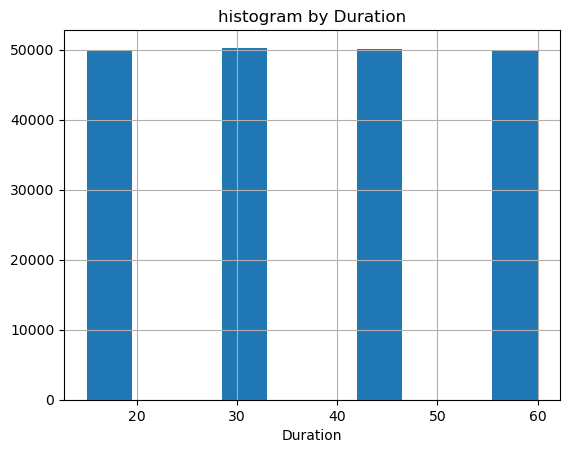

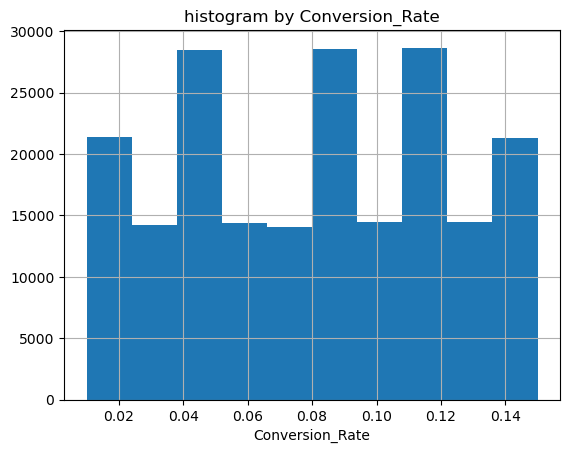

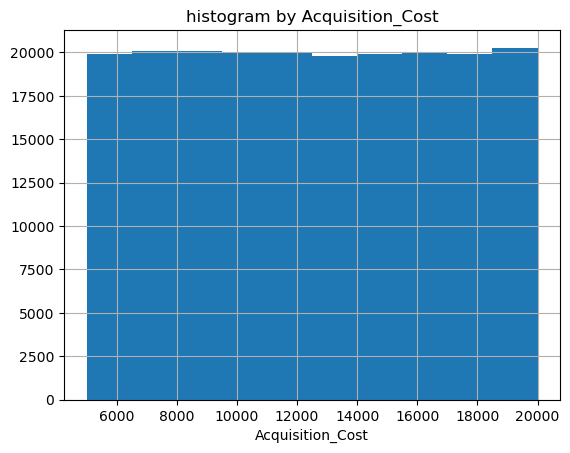

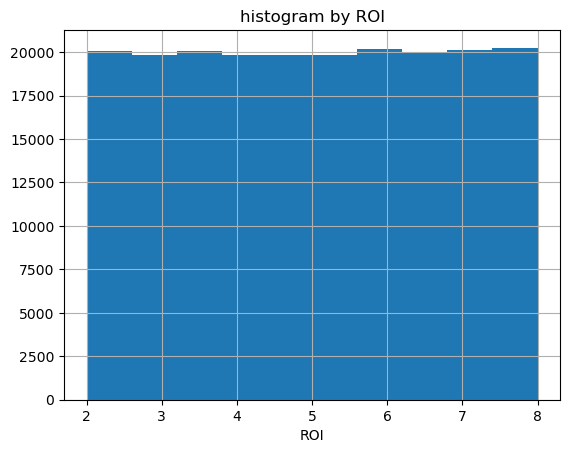

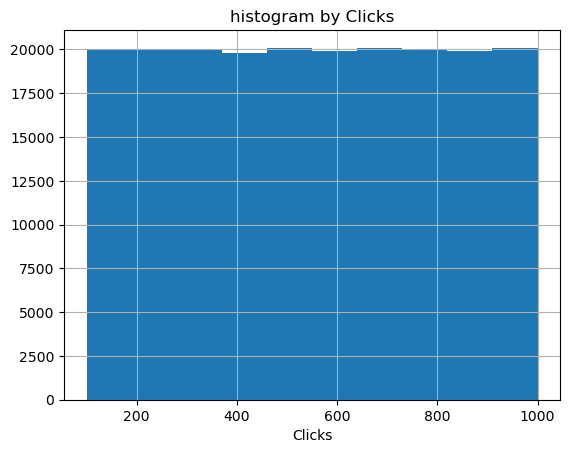

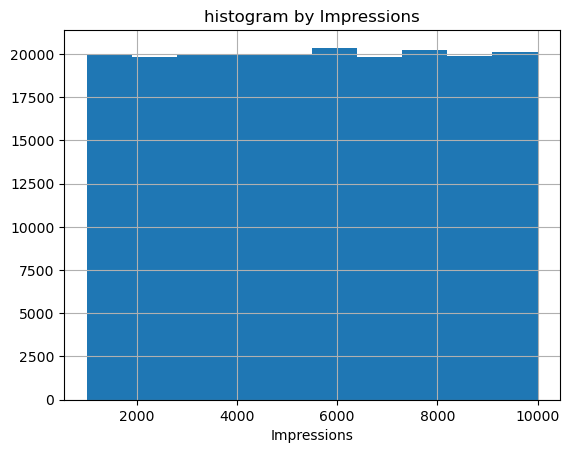

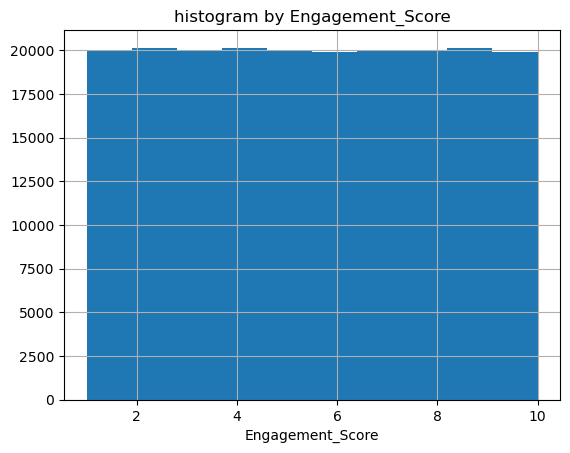

In [ ]:
for i in numeric_cols:
    df.hist(i)
    plt.title(f'histogram by {i}')
    plt.xlabel(i)

In [ ]:
df.columns

Index(['Company', 'Campaign_Type', 'Duration', 'Channel_Used',
       'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language',
       'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date',
       'Gender', 'Age_group'],
      dtype='object')

In [ ]:
df.head(5)

,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Gender,Age_group
0,Innovate Industries,Email,30,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,Men,18-24
1,NexGen Systems,Email,60,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,Women,35-44
2,Alpha Innovations,Influencer,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,Men,25-34
3,DataTech Solutions,Display,60,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,All,Ages
4,NexGen Systems,Email,15,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,Men,25-34


In [ ]:
#Find the top 5 Campaign_Type with the highest average ROI.

In [ ]:
df.groupby('Campaign_Type')['ROI'].mean()

Campaign_Type
Display         5.006551
Email           4.994295
Influencer      5.011068
Search          5.008357
Social Media    4.991784
Name: ROI, dtype: float64

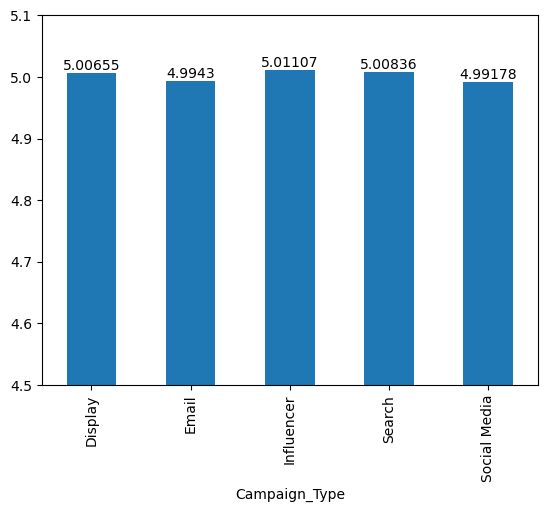

In [ ]:
ax=df.groupby('Campaign_Type')['ROI'].mean().plot(kind='bar',ylim=[4.5,5.1])
plt.bar_label(ax.containers[0])
plt.show()

In [ ]:
from scipy.stats import f_oneway

In [ ]:
df['Campaign_Type'].unique()

array(['Email', 'Influencer', 'Display', 'Search', 'Social Media'],
      dtype=object)

In [ ]:
groups=[df[df['Campaign_Type']==x]['ROI'].values for x in df['Campaign_Type'].unique()]

In [ ]:
statistic,p_val=f_oneway(*groups)
print(f'p_val is {p_val}')

p_val is 0.396876488216765


In [ ]:
if p_val>0.05:
    print(f'p_val: {p_val} - Difference is because of random chance')
else:
    print(f'p_val: {p_val} - Theres a difference')

p_val: 0.396876488216765 - Difference is because of random chance


In [ ]:
#Compare average Conversion_Rate across Campaign_Type.

In [ ]:
df.head()

,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Gender,Age_group
0,Innovate Industries,Email,30,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,Men,18-24
1,NexGen Systems,Email,60,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,Women,35-44
2,Alpha Innovations,Influencer,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,Men,25-34
3,DataTech Solutions,Display,60,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,All,Ages
4,NexGen Systems,Email,15,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,Men,25-34


In [ ]:
round(df.groupby('Campaign_Type')['Conversion_Rate'].mean(),4)

Campaign_Type
Display         0.0801
Email           0.0798
Influencer      0.0803
Search          0.0800
Social Media    0.0801
Name: Conversion_Rate, dtype: float64

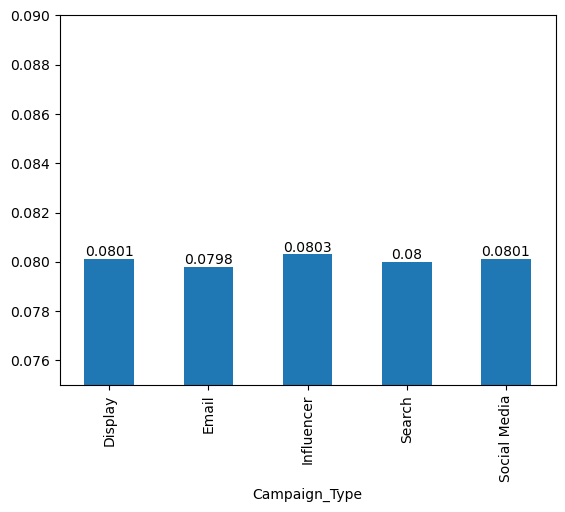

In [ ]:
CR=round(df.groupby('Campaign_Type')['Conversion_Rate'].mean(),4).plot(kind='bar',ylim=[0.075,0.09])
plt.bar_label(CR.containers[0])
plt.show()

In [ ]:
#Which Channel_Used generates the highest Clicks-to-Impressions ratio?

In [ ]:
df['Channel_Used'].unique()

array(['Google Ads', 'YouTube', 'Instagram', 'Website', 'Facebook',
       'Email'], dtype=object)

In [ ]:
df['Clicks-to-Impressions']=df['Clicks']/df['Impressions']

In [ ]:
df.groupby('Channel_Used')['Clicks-to-Impressions'].sum().sort_values(ascending=False)

Channel_Used
Email         4722.093817
YouTube       4714.818606
Website       4702.804661
Instagram     4676.112476
Google Ads    4654.224308
Facebook      4611.045200
Name: Clicks-to-Impressions, dtype: float64

In [ ]:
(df.groupby('Channel_Used')['Clicks'].sum()/df.groupby('Channel_Used')['Impressions'].sum()).sort_values(ascending=False)

Channel_Used
Website       0.100185
Email         0.100075
YouTube       0.100031
Facebook      0.099845
Instagram     0.099689
Google Ads    0.099136
dtype: float64

In [ ]:
# Analyze ROI distribution for each Customer_Segment.

In [ ]:
df['Customer_Segment'].unique()

array(['Health & Wellness', 'Fashionistas', 'Outdoor Adventurers',
       'Foodies', 'Tech Enthusiasts'], dtype=object)

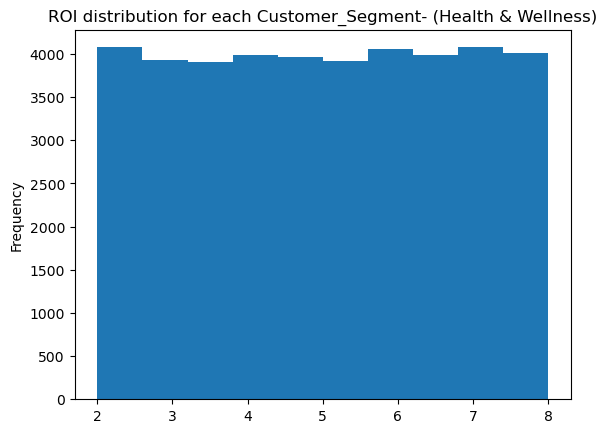

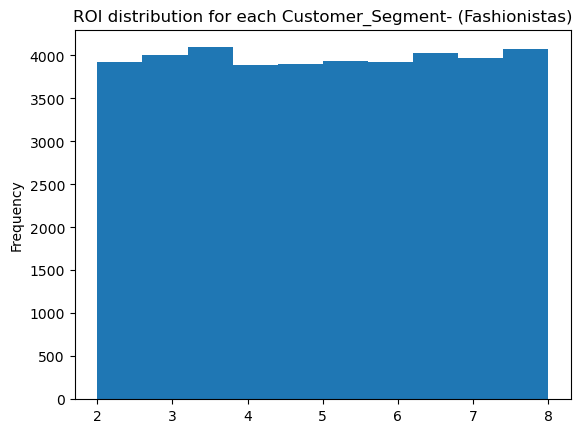

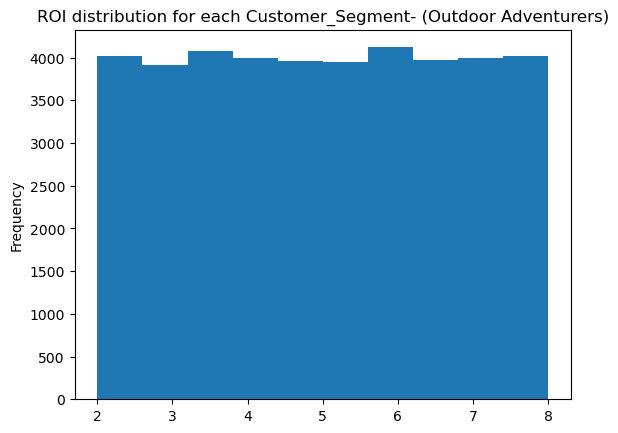

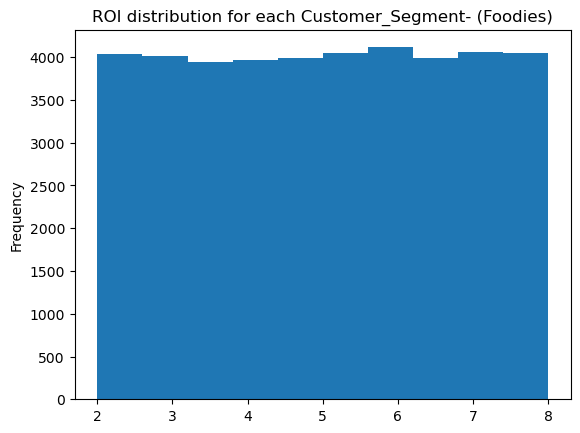

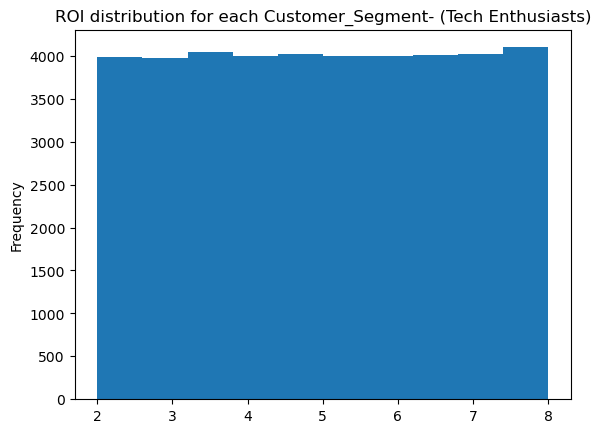

In [ ]:
for i in df['Customer_Segment'].unique():
    df[df['Customer_Segment']==i]['ROI'].plot(kind='hist')
    plt.title(f'ROI distribution for each Customer_Segment- ({i})')
    plt.show()


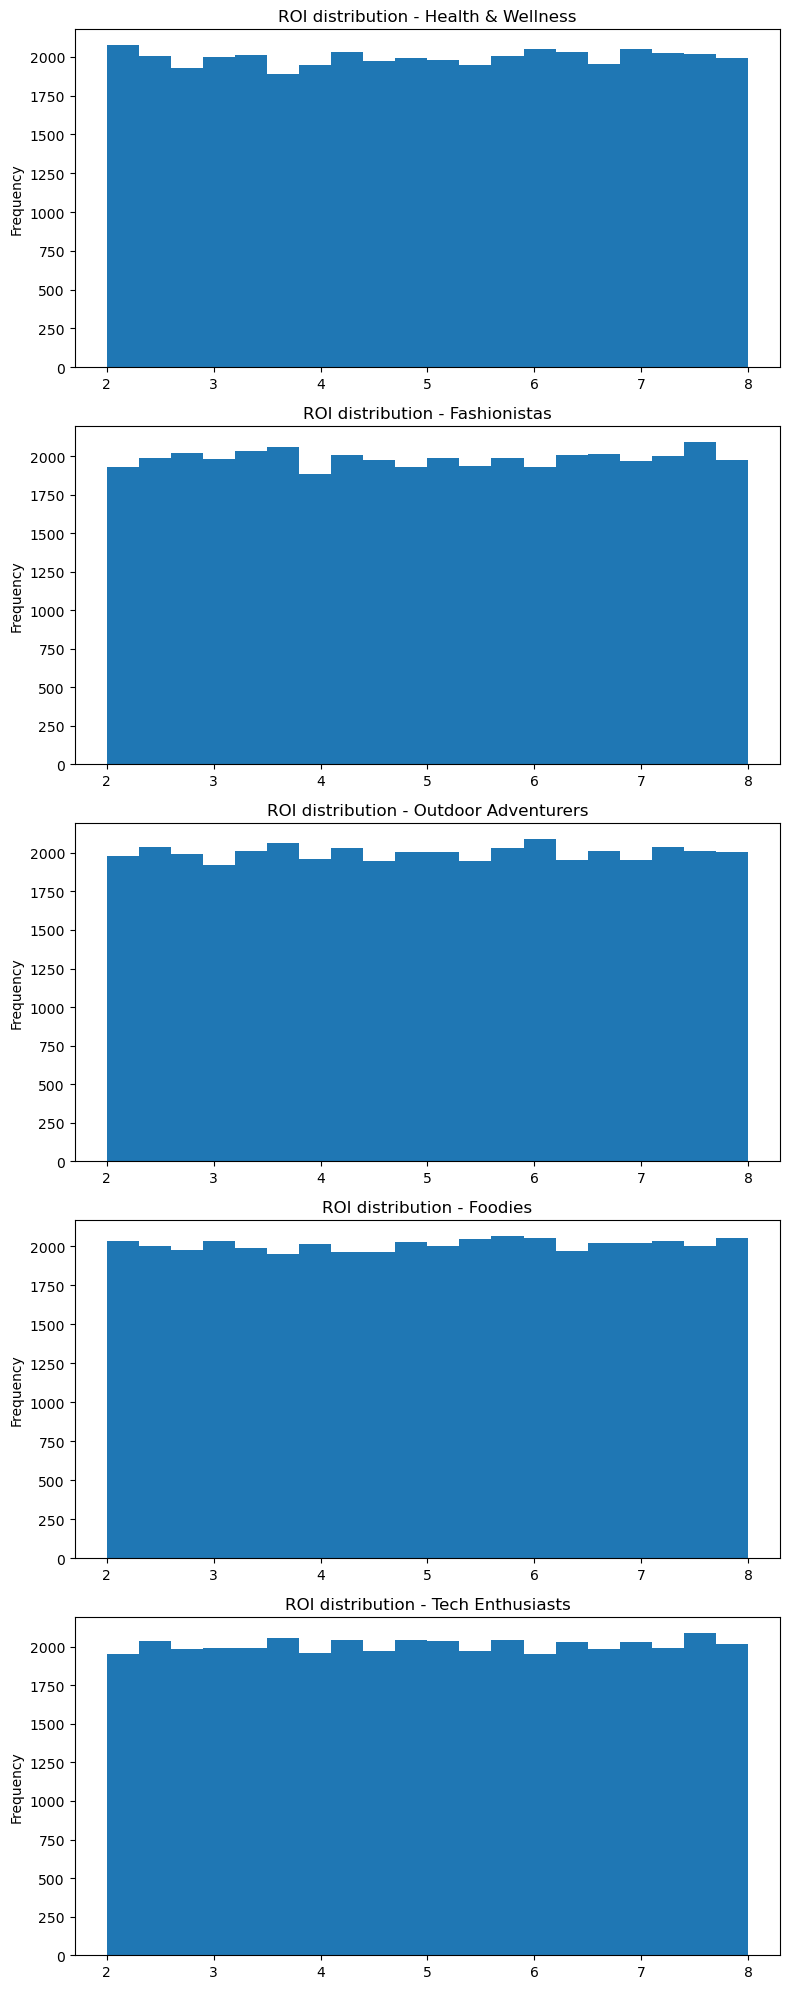

In [ ]:
segments = df['Customer_Segment'].unique()
fig, axes = plt.subplots(len(segments), 1, figsize=(8, 4*len(segments)))

for ax, seg in zip(axes, segments):
    df[df['Customer_Segment'] == seg]['ROI'].plot(kind='hist', ax=ax, bins=20)
    ax.set_title(f'ROI distribution - {seg}')
plt.tight_layout()
plt.show()

In [ ]:
#Find campaigns with above-average ROI but below-average Acquisition_Cost.

In [ ]:
df1=df[(df['ROI']>df['ROI'].mean()) & (df['Acquisition_Cost']<df['Acquisition_Cost'].mean())]

In [ ]:
round(df[(df['ROI']>df['ROI'].mean()) & (df['Acquisition_Cost']<df['Acquisition_Cost'].mean())].shape[0]/df.shape[0]*100,2)

25.01

/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


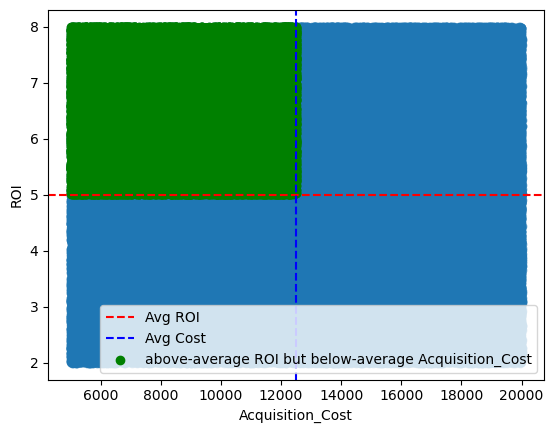

In [ ]:
avg_roi=df['ROI'].mean()
avg_cost=df['Acquisition_Cost'].mean()

plt.scatter(df['Acquisition_Cost'], df['ROI'], alpha=0.6)
plt.axhline(avg_roi, color='red', linestyle='--', label='Avg ROI')
plt.axvline(avg_cost, color='blue', linestyle='--', label='Avg Cost')

plt.scatter(df1['Acquisition_Cost'],df1['ROI'],color='green',label='above-average ROI but below-average Acquisition_Cost')
plt.legend()
plt.xlabel('Acquisition_Cost')
plt.ylabel('ROI')
plt.show()

### Which Age_group has the highest engagement?

In [ ]:
df['Age_group']=df['Age_group'].str.replace('Ages','All')

In [ ]:
df.groupby('Age_group')['Engagement_Score'].mean()

Age_group
18-24    5.515078
25-34    5.492341
35-44    5.486507
All      5.487094
Name: Engagement_Score, dtype: float64

In [ ]:
mean_engagement=df['Engagement_Score'].mean()

In [ ]:
mean_engagement

np.float64(5.49471)

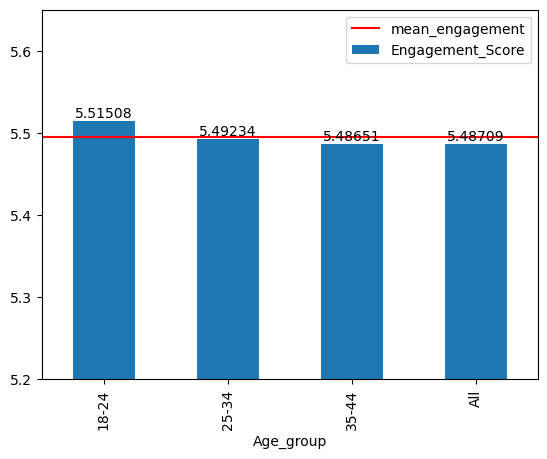

In [ ]:
ax=df.groupby('Age_group')['Engagement_Score'].mean().plot(kind='bar',ylim=[5.2,5.65])
plt.axhline(mean_engagement,color='red',label='mean_engagement')
plt.bar_label(ax.containers[0])
plt.legend()
plt.show()



In [ ]:
df[df['Engagement_Score']>mean_engagement]['Engagement_Score'].mean()

np.float64(8.001774453879237)

In [ ]:
above_mean=df[df['Engagement_Score']>mean_engagement]
above_mean.groupby('Age_group')['Engagement_Score'].mean()

Age_group
18-24    8.002617
25-34    7.997637
35-44    8.004408
All      8.006554
Name: Engagement_Score, dtype: float64

In [ ]:
df[df['Engagement_Score']>mean_engagement]['Age_group'].value_counts()

Age_group
25-34    39777
18-24    20249
All      19988
35-44    19735
Name: count, dtype: int64

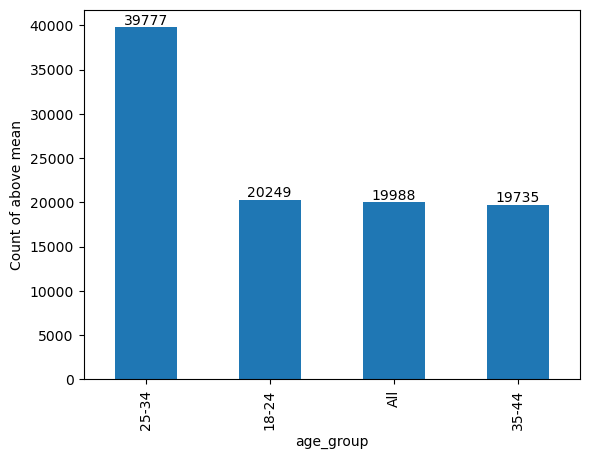

In [ ]:
age=df[df['Engagement_Score']>mean_engagement]['Age_group'].value_counts().plot(kind='bar')
plt.bar_label(age.containers[0])
plt.xlabel('age_group')
plt.ylabel('Count of above mean')
plt.show()

In [ ]:
val=[df[df['Age_group']==x]['Engagement_Score'].values for x in df['Age_group'].unique()]

In [ ]:
stat,p_val=f_oneway(*val)
if p_val>0.05:
    print('Theres no difference')
else:
    print('Theres difference')

Theres no difference


<Axes: title={'center': 'Engagement_Score'}, xlabel='Age_group'>

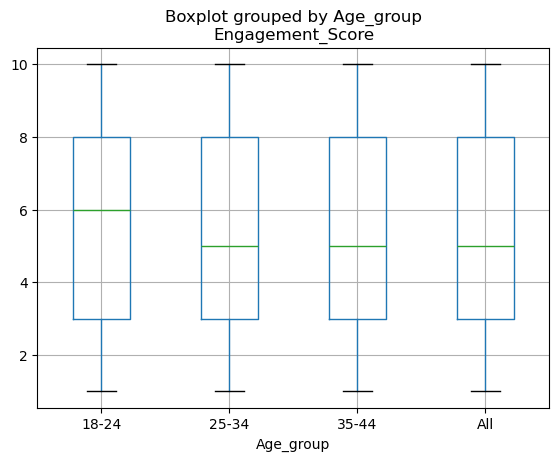

In [ ]:
df.boxplot('Engagement_Score',by='Age_group')

### Detect skewness in numerical columns.

In [ ]:
num_cols=df.select_dtypes(include=np.number)

In [ ]:
for i in num_cols:
    print(f'skewness of {i}: {df[i].skew()}')


skewness of Duration: 0.00027330197947957085
skewness of Conversion_Rate: -0.003410794607730609
skewness of Acquisition_Cost: 0.001846085318847208
skewness of ROI: -0.005043390809755747
skewness of Clicks: 0.0014226725719625425
skewness of Impressions: -0.004118345632554376
skewness of Engagement_Score: 0.0025509786048324
skewness of Clicks-to-Impressions: 2.315530374777656


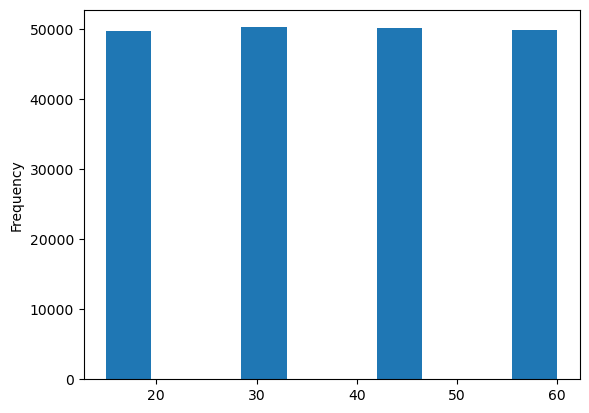

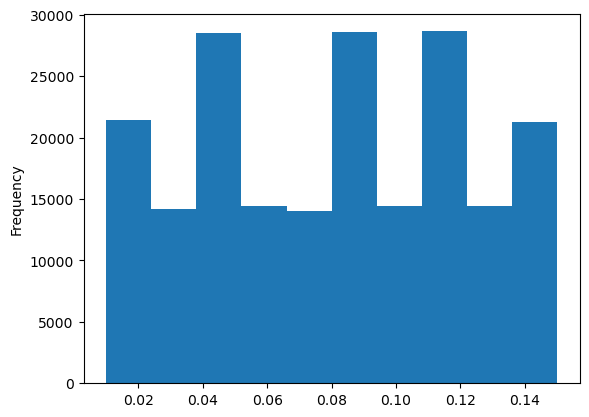

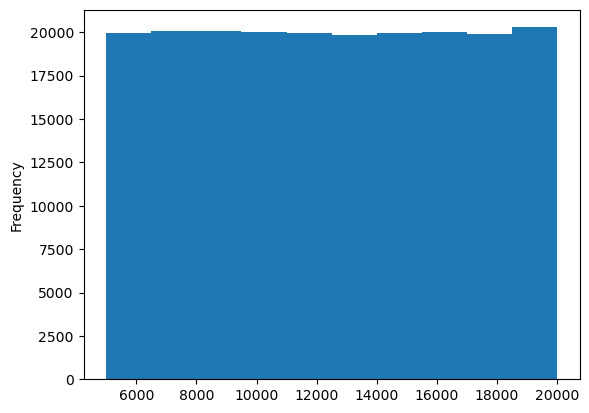

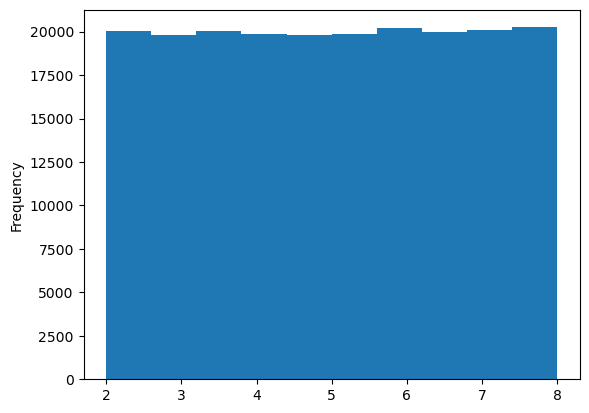

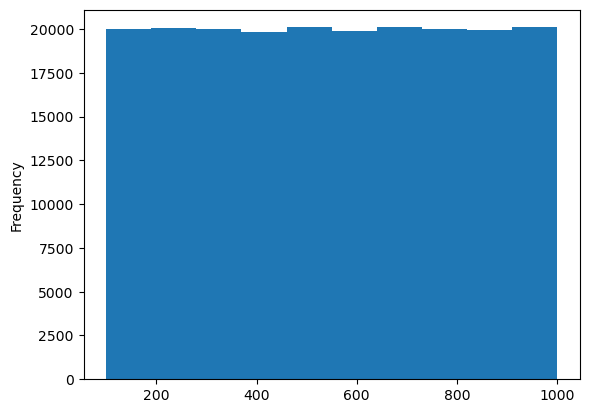

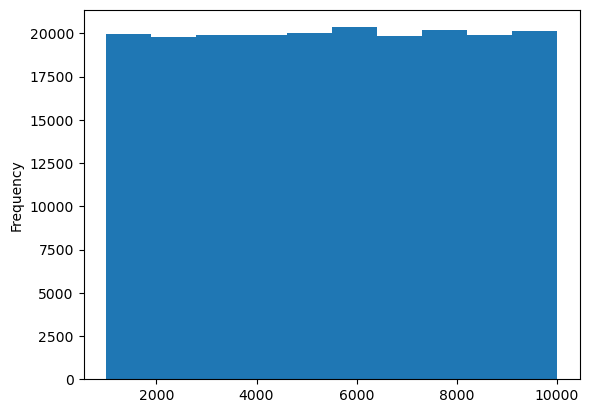

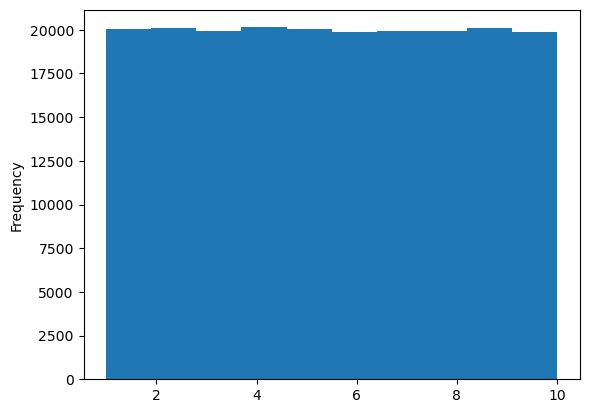

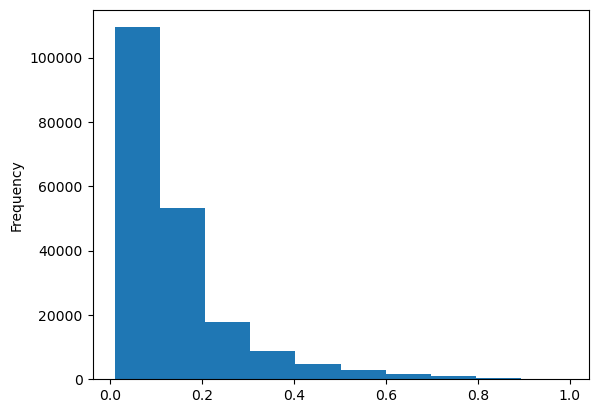

In [ ]:
from pandas.api.types import is_numeric_dtype
for col in df.columns:
    if is_numeric_dtype(df[col]):
        df[col].plot(kind='hist')
        plt.show()


for col in df.columns:
    if np.issubdtype(df[col].dtype, np.number):
        df[col].plot(kind='hist', title=col)
        plt.show()

### Find correlation between Clicks, Impressions, Engagement_Score, and ROI.

In [ ]:
cols=['Clicks','Impressions','Engagement_Score','ROI']
for i in cols:
    print(f'corr with {i}: {df[['Clicks','Impressions','Engagement_Score','ROI']].corrwith(df[i])}')

corr with Clicks: Clicks              1.000000
Impressions         0.000033
Engagement_Score   -0.001908
ROI                -0.002040
dtype: float64
corr with Impressions: Clicks              0.000033
Impressions         1.000000
Engagement_Score    0.003030
ROI                 0.002257
dtype: float64
corr with Engagement_Score: Clicks             -0.001908
Impressions         0.003030
Engagement_Score    1.000000
ROI                 0.000588
dtype: float64
corr with ROI: Clicks             -0.002040
Impressions         0.002257
Engagement_Score    0.000588
ROI                 1.000000
dtype: float64


In [ ]:
df[cols].corr()

,Clicks,Impressions,Engagement_Score,ROI
Clicks,1.000000,0.000033,-0.001908,-0.002040
Impressions,0.000033,1.000000,0.003030,0.002257
Engagement_Score,-0.001908,0.003030,1.000000,0.000588
ROI,-0.002040,0.002257,0.000588,1.000000


### Which Location performs best in terms of Conversion_Rate?

In [ ]:
df.groupby('Location')['Conversion_Rate'].mean()

Location
Chicago        0.080134
Houston        0.079948
Los Angeles    0.080013
Miami          0.080047
New York       0.080204
Name: Conversion_Rate, dtype: float64

In [ ]:
l=[df[df['Location']==x]['Conversion_Rate'].values for x in df['Location'].unique()]

In [ ]:
f_oneway(*l)

F_onewayResult(statistic=np.float64(0.24628352230364803), pvalue=np.float64(0.9120413310933907))

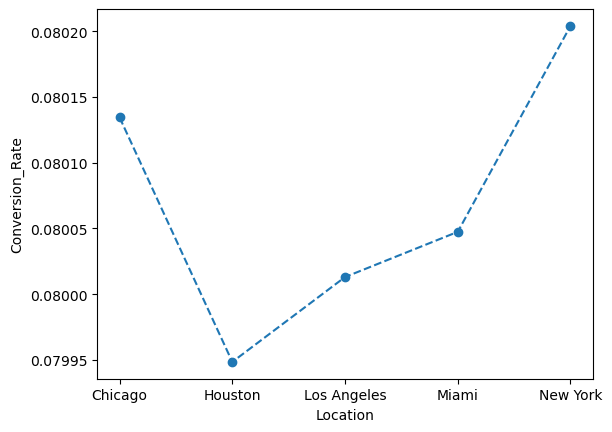

In [ ]:
line=df.groupby('Location')['Conversion_Rate'].mean().reset_index()
plt.plot(line['Location'],line['Conversion_Rate'],linestyle='--',marker='o')
plt.ylabel('Conversion_Rate')
plt.xlabel('Location')
plt.show()


In [ ]:
count=df['Location'].value_counts().reset_index()
count

,Location,count
0,Miami,40269
1,New York,40024
2,Chicago,40010
3,Los Angeles,39947
4,Houston,39750


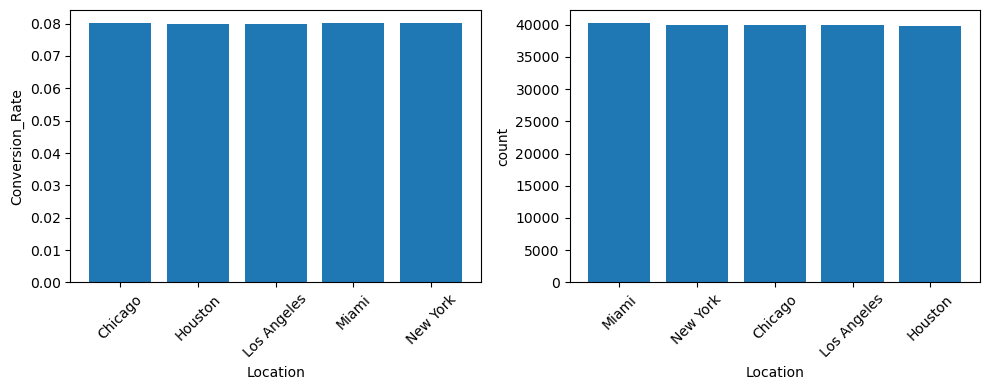

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(10,4))

axes[0].bar(line['Location'],line['Conversion_Rate'])
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Conversion_Rate')
axes[0].tick_params(axis='x',rotation=45)

axes[1].bar(count['Location'],count['count'])
axes[1].set_xlabel('Location')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()





### Create Cost_Per_Click feature.

In [ ]:
df['CPC']=df['Acquisition_Cost']/df['Clicks']
print(df['CPC'].head(5))

0    31.964427
1    99.706897
2    17.465753
3    58.635945
4    43.408971
Name: CPC, dtype: float64


### Extract month and weekday from Date.

In [ ]:
df.columns

Index(['Company', 'Campaign_Type', 'Duration', 'Channel_Used',
       'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language',
       'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date',
       'Gender', 'Age_group', 'Clicks-to-Impressions', 'CPC'],
      dtype='object')

In [ ]:
df['Month']=df['Date'].dt.month

In [ ]:
df['Weekday']=df['Date'].dt.weekday

In [ ]:
df.head(5)

,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Gender,Age_group,Clicks-to-Impressions,CPC,Month,Weekday
0,Innovate Industries,Email,30,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,Men,18-24,0.263267,31.964427,1,4
1,NexGen Systems,Email,60,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,Women,35-44,0.015419,99.706897,1,5
2,Alpha Innovations,Influencer,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,Men,25-34,0.075864,17.465753,1,6
3,DataTech Solutions,Display,60,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,All,All,0.119231,58.635945,1,0
4,NexGen Systems,Email,15,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,Men,25-34,0.090217,43.408971,1,1


### Create ROI categories: Low, Medium, High

In [ ]:
q1=df['ROI'].quantile(0.25)
q2=df['ROI'].quantile(0.5)
q3=df['ROI'].quantile(0.75)

In [ ]:
df['roi_category']=np.where(df['ROI']<=q1,'Low',np.where(df['ROI']<=q3,'Medium','High'))

In [ ]:
df['roi_category'].head(5)

0    Medium
1    Medium
2      High
3    Medium
4    Medium
Name: roi_category, dtype: object

### Handle outliers in Acquisition_Cost using IQR.

In [ ]:
q1=df['Acquisition_Cost'].quantile(0.25)

In [ ]:
q3=df['Acquisition_Cost'].quantile(0.75)

In [ ]:
iqr=q3-q1

In [ ]:
upper_limit=q3+(1.5*iqr)

In [ ]:
lower_limit=q1-(1.5*iqr)

In [ ]:
print('upper limit:',upper_limit)
print('lower limit:',lower_limit)

upper limit: 27550.375
lower limit: -2546.625


In [ ]:
df[(df['Acquisition_Cost']>upper_limit) | (df['Acquisition_Cost']<lower_limit)]

,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,...,Engagement_Score,Customer_Segment,Date,Gender,Age_group,Clicks-to-Impressions,CPC,Month,Weekday,roi_category


### Create a feature representing campaign efficiency.

In [ ]:
df.columns

Index(['Company', 'Campaign_Type', 'Duration', 'Channel_Used',
       'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language',
       'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date',
       'Gender', 'Age_group', 'Clicks-to-Impressions', 'CPC', 'Month',
       'Weekday', 'roi_category'],
      dtype='object')

In [ ]:
df['efficiency']=df['ROI']/df['Acquisition_Cost']

### Test whether ROI differs significantly across channels.

In [ ]:
ch=[df[df['Channel_Used']==x]['ROI'].values for x in df['Channel_Used'].unique()]

In [ ]:
f_oneway(*ch)

F_onewayResult(statistic=np.float64(1.5481940084456922), pvalue=np.float64(0.17110640889797826))

In [ ]:
# kruskal wallis

from scipy import stats
stats,p_val=stats.kruskal(*ch)

if p_val<0.05:
    print('Theres difference')
else:
    print('No difference')

No difference


### Perform ANOVA on Campaign_Type vs Conversion_Rate.

In [ ]:
c=[df[df['Campaign_Type']==x]['Conversion_Rate'].values for x in df['Campaign_Type'].unique()]

In [ ]:
f_oneway(*c)

F_onewayResult(statistic=np.float64(0.8872620760594465), pvalue=np.float64(0.4704618058592427))

In [ ]:
from scipy import stats
stats,p_val=stats.kruskal(*c)
print('statistic',stats)
print('pvalue',p_val)

statistic 3.5118692925680013
pvalue 0.4760758890584519


### Check if Engagement_Score impacts Conversion_Rate statistically.

In [ ]:
df['Engagement_Score'].corr(df['Conversion_Rate'])

np.float64(-0.0006383944320044995)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

lr=LinearRegression()

x=df[['Engagement_Score']]
y=df['Conversion_Rate']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
lr.fit(x_train,y_train)
pred=lr.predict(x_test)

print('r2_score is',r2_score(y_test,pred))


r2_score is -1.2349391735666515e-05


In [ ]:
import statsmodels.api as sm

In [ ]:
from scipy import stats
pearson_r, p_val = stats.pearsonr(data['Engagement_Score'], data['Conversion_Rate'])
print("Pearson r:", pearson_r, "p-value:", p_val)

# --- Regression ---
X = sm.add_constant(data['Engagement_Score'])
y = data['Conversion_Rate']
model = sm.OLS(y, X).fit()
print(model.summary())

Pearson r: -0.0006383944320057155 p-value: 0.7752634683415138
                            OLS Regression Results                            
Dep. Variable:        Conversion_Rate   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.08151
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.775
Time:                        18:07:13   Log-Likelihood:             3.5700e+05
No. Observations:              200000   AIC:                        -7.140e+05
Df Residuals:                  199998   BIC:                        -7.140e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

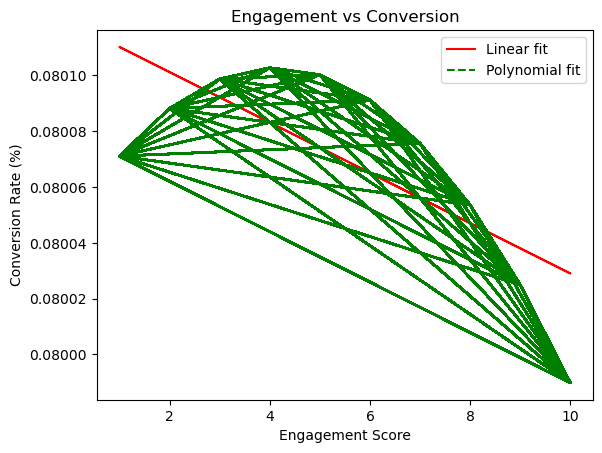

In [ ]:
pred_line = model.predict(X)

plt.plot(data['Engagement_Score'], pred_line, color='red', label='Linear fit')

# --- Optional: Polynomial fit (to check non-linear patterns) ---
z = np.polyfit(data['Engagement_Score'], data['Conversion_Rate'], 2)  # quadratic
p = np.poly1d(z)
plt.plot(data['Engagement_Score'], p(data['Engagement_Score']), color='green', linestyle='--', label='Polynomial fit')
plt.xlabel("Engagement Score")
plt.ylabel("Conversion Rate (%)")
plt.title("Engagement vs Conversion")
plt.legend()
plt.show()

### Perform hypothesis testing between men and women campaign performance.

In [ ]:
df.columns

Index(['Company', 'Campaign_Type', 'Duration', 'Channel_Used',
       'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language',
       'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date',
       'Gender', 'Age_group', 'Clicks-to-Impressions', 'CPC', 'Month',
       'Weekday', 'roi_category', 'efficiency'],
      dtype='object')

In [ ]:
men=df.loc[df['Gender']=='Men','ROI']

In [ ]:
women=df.loc[df['Gender']=='Women','ROI']

In [ ]:
men_mean=men.mean()
women_mean=women.mean()

men_std=men.std()
women_std=women.std()
t_test=(women_mean-men_mean)/np.sqrt((women_std**2/women.count())+(men_std**2/men.count()))
print('ttest',t_test)

ttest 0.015835929161291642


In [ ]:
from scipy.stats import ttest_ind

In [ ]:
stats,p_val=ttest_ind(women,men)
print('stats',stats)
print('p_val',p_val)

stats 0.015835838399173793
p_val 0.9873653768564978


### Identify confidence interval for mean ROI.

In [ ]:
# formula: mean+-z(s/np.sqrt(n))

mean_roi=df['ROI'].mean()
std_roi=df['ROI'].std()
count=df['ROI'].count()

lower_limit=mean_roi-1.96*(std_roi/np.sqrt(count))
upper_limit=mean_roi+1.96*(std_roi/np.sqrt(count))

print('lower_limit',lower_limit)
print('upper_limit',upper_limit)

lower_limit 4.994836119669323
upper_limit 5.010039580330677


In [ ]:
df['ROI'].mean()

np.float64(5.00243785)

In [ ]:
# built in function

from scipy import stats
sem=stats.sem(df['ROI'])
ci=stats.t.interval(confidence=0.95,df=len(df['ROI'])-1,loc=mean_roi,scale=sem)
print('Class interval:',ci)

Class interval: (np.float64(4.994836213348913), np.float64(5.0100394866510864))


### Perform chi-square test between Gender and Campaign_Type

In [ ]:
df.columns

Index(['Company', 'Campaign_Type', 'Duration', 'Channel_Used',
       'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language',
       'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date',
       'Gender', 'Age_group', 'Clicks-to-Impressions', 'CPC', 'Month',
       'Weekday', 'roi_category', 'efficiency'],
      dtype='object')

In [ ]:
table=pd.crosstab(df['Gender'],df['Campaign_Type'])

In [ ]:
from scipy.stats import chi2_contingency
stats,p_val,dof,expected=chi2_contingency(table)

print('statistics:',stats)
print('p_value:',p_val)
print('degree of freedom:',dof)
print('expected:',expected)

statistics: 22.55980602619765
p_value: 0.003977853739804723
degree of freedom: 8
expected: [[ 8001.198765  7977.78765   8037.616055  8035.214915  7967.182615]
 [16050.981735 16004.01735  16124.037445 16119.220585 15982.742885]
 [15934.8195   15888.195    16007.3465   16002.5645   15867.0745  ]]


### Identify statistically significant predictors of ROI.

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

In [ ]:
x=df.drop(columns=['ROI','Date'])
y=round(df['ROI'],0)

In [ ]:
cat_cols=x.select_dtypes(include='object').columns

In [ ]:
for i in cat_cols:
    le=LabelEncoder()
    x[i]=le.fit_transform(x[i])
    print(x[i])


0         2
1         3
2         0
3         1
4         3
         ..
199995    4
199996    1
199997    1
199998    2
199999    2
Name: Company, Length: 200000, dtype: int32
0         1
1         1
2         2
3         0
4         1
         ..
199995    0
199996    1
199997    4
199998    2
199999    4
Name: Campaign_Type, Length: 200000, dtype: int32
0         2
1         2
2         5
3         5
4         5
         ..
199995    2
199996    1
199997    4
199998    5
199999    2
Name: Channel_Used, Length: 200000, dtype: int32
0         0
1         4
2         2
3         3
4         2
         ..
199995    0
199996    0
199997    4
199998    1
199999    0
Name: Location, Length: 200000, dtype: int32
0         4
1         2
2         1
3         3
4         3
         ..
199995    2
199996    4
199997    3
199998    1
199999    4
Name: Language, Length: 200000, dtype: int32
0         2
1         0
2         3
3         2
4         2
         ..
199995    4
199996    1
199997    4

In [ ]:
from sklearn.preprocessing import MinMaxScaler
ss=MinMaxScaler()

x_transform=ss.fit_transform(x)


In [ ]:
x_transform

array([[0.5       , 0.25      , 0.33333333, ..., 0.66666667, 1.        ,
        0.19355742],
       [0.75      , 0.25      , 1.        , ..., 0.83333333, 1.        ,
        0.25802169],
       [0.        , 0.5       , 0.33333333, ..., 1.        , 0.        ,
        0.40477558],
       ...,
       [0.25      , 1.        , 0.66666667, ..., 0.5       , 0.5       ,
        0.09546358],
       [0.5       , 0.5       , 0.33333333, ..., 0.66666667, 1.        ,
        0.07264506],
       [0.5       , 1.        , 0.66666667, ..., 0.83333333, 0.        ,
        0.25460212]], shape=(200000, 20))

In [ ]:
chi=chi2(x_transform,y)

In [ ]:
pd.DataFrame(np.transpose(chi),columns=['Chi_val','p_val'],index=x.columns)

,Chi_val,p_val
Company,0.531597,0.997432
Campaign_Type,2.037970,0.916174
Duration,2.595580,0.857621
Channel_Used,1.564845,0.955071
Conversion_Rate,0.550724,0.997165
Acquisition_Cost,1.271022,0.973232
Location,0.978060,0.986430
Language,1.668830,0.947502
Clicks,0.730304,0.993814
Impressions,0.758364,0.993144


In [ ]:
chi,p_val=chi

In [ ]:
pd.DataFrame(list(zip(chi,p_val)))

,0,1
0,0.531597,0.997432
1,2.037970,0.916174
2,2.595580,0.857621
3,1.564845,0.955071
4,0.550724,0.997165
5,1.271022,0.973232
6,0.978060,0.986430
7,1.668830,0.947502
8,0.730304,0.993814
9,0.758364,0.993144


### Analyze seasonal trends using Date.

In [ ]:
df.columns

Index(['Company', 'Campaign_Type', 'Duration', 'Channel_Used',
       'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language',
       'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date',
       'Gender', 'Age_group', 'Clicks-to-Impressions', 'CPC', 'Month',
       'Weekday', 'roi_category', 'efficiency'],
      dtype='object')

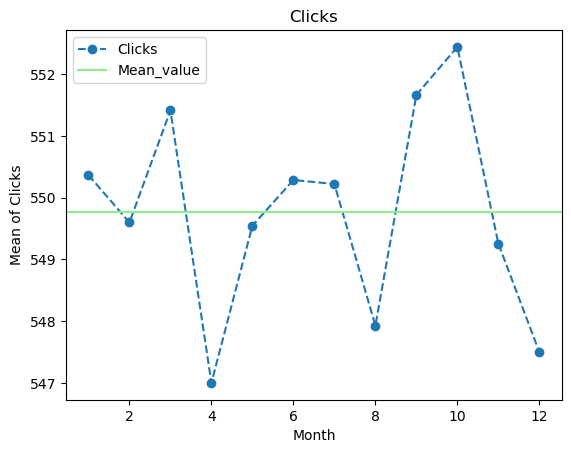

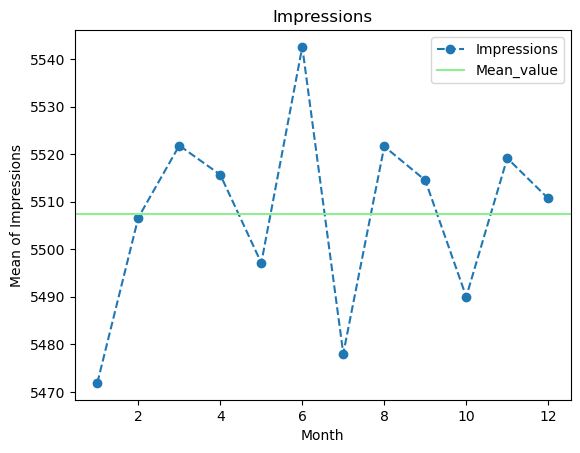

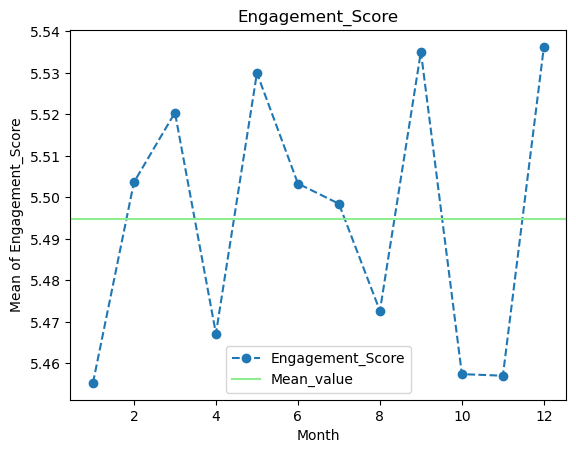

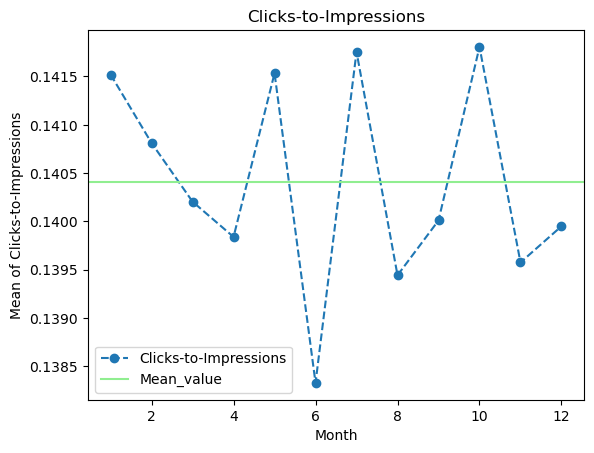

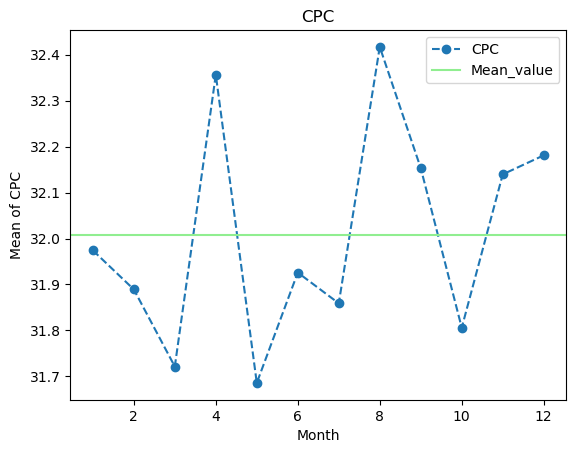

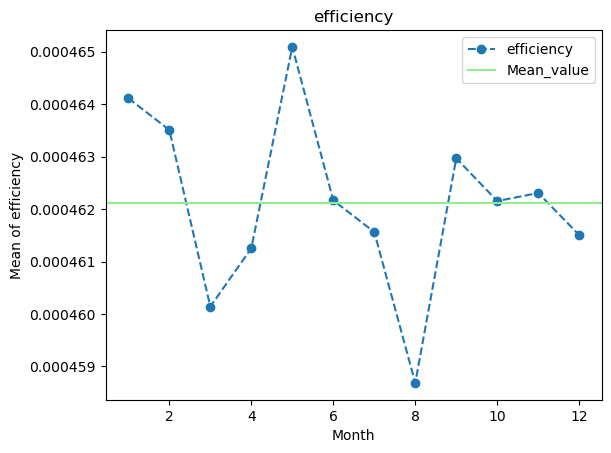

In [ ]:
for i in df[['Clicks', 'Impressions', 'Engagement_Score','Clicks-to-Impressions','CPC','efficiency']]:
    df.groupby('Month')[i].mean().plot(linestyle='--',marker='o',label=i)
    plt.axhline(df[i].mean(),color='lightgreen',label='Mean_value')
    plt.title(i)
    plt.xlabel('Month')
    plt.ylabel(f'Mean of {i}')
    plt.legend()
    plt.show()

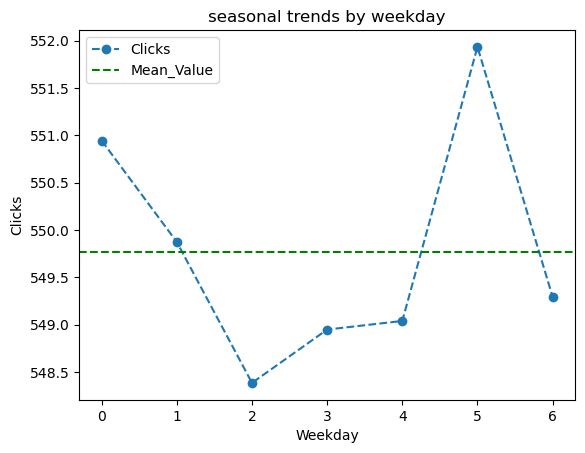

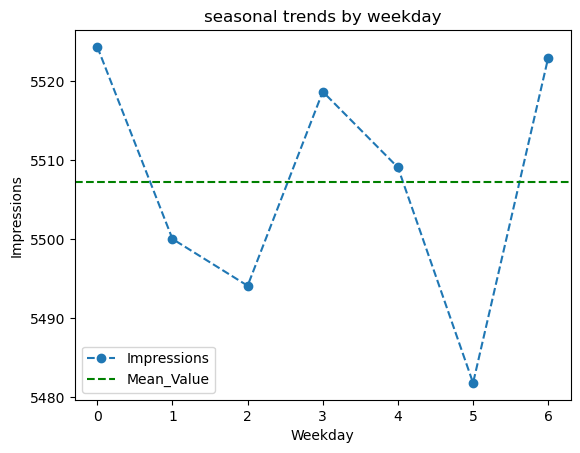

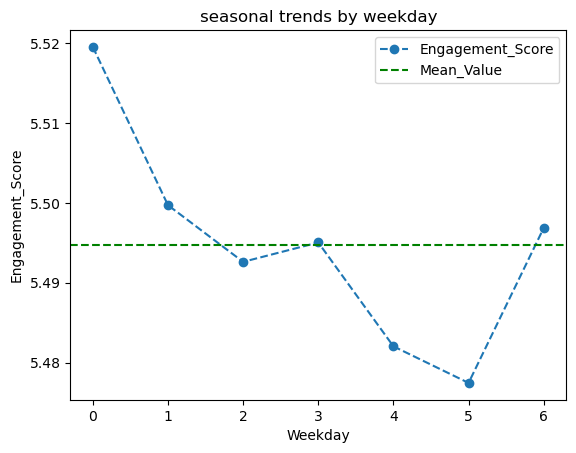

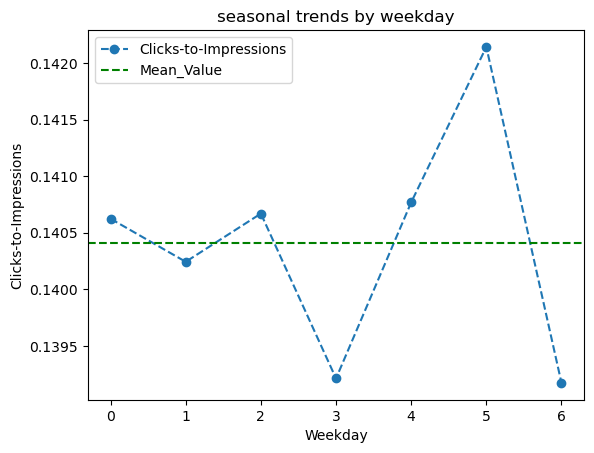

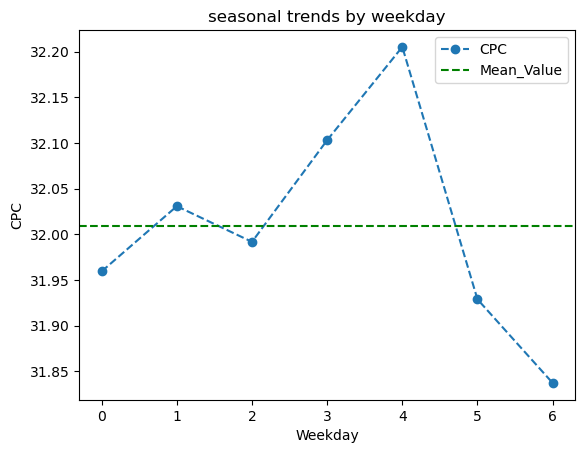

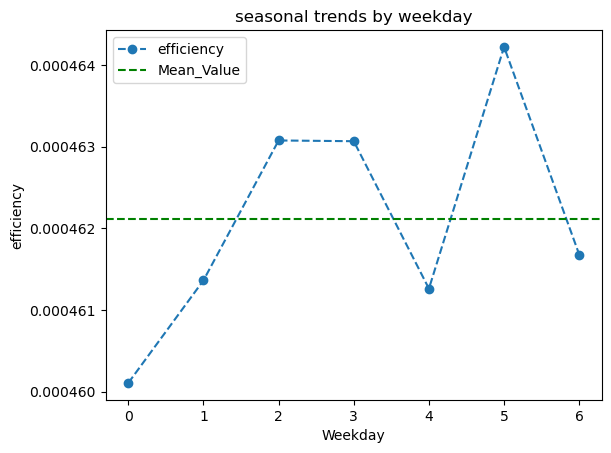

In [ ]:
for i in ['Clicks', 'Impressions', 'Engagement_Score','Clicks-to-Impressions', 'CPC','efficiency']:
    df.groupby('Weekday')[i].mean().plot(linestyle='--',marker='o',label=i)
    plt.title('seasonal trends by weekday')
    plt.axhline(df[i].mean(),color='green',label='Mean_Value',linestyle='--')
    plt.xlabel('Weekday')
    plt.ylabel(i)
    plt.legend()
    plt.show()


In [ ]:
cols=['Clicks', 'Impressions', 'Engagement_Score','Clicks-to-Impressions', 'CPC','efficiency']

for i in cols:
    c=[df[df['Month']==x][i] for x in df['Month'].unique()]
    stats,p_val=f_oneway(*c)
    print(f'\n{i}:\n')
    print('statistic',stats)
    print('p_value',p_val)


Clicks:

statistic 0.6939663348233308
p_value 0.7456958146484778

Impressions:

statistic 1.0072489638742306
p_value 0.43661220980061893

Engagement_Score:

statistic 2.0388834664486546
p_value 0.021266460654073942

Clicks-to-Impressions:

statistic 1.165322441190509
p_value 0.30535863705516286

CPC:

statistic 1.3235626270332035
p_value 0.20358971087607114

efficiency:

statistic 0.7509046408273048
p_value 0.6898444998297245


### Compare campaign durations using boxplots and statistics.

In [ ]:
df.groupby('Duration')[['Engagement_Score','ROI','efficiency','Clicks','Impressions']].agg(['mean','count'])

Engagement_Score              ROI        efficiency         \
                     mean  count      mean  count       mean  count   
Duration                                                              
15               5.502260  49779  4.996720  49779   0.000462  49779   
30               5.505064  50255  5.008887  50255   0.000464  50255   
45               5.489960  50100  4.997627  50100   0.000461  50100   
60               5.481510  49866  5.006480  49866   0.000462  49866   

              Clicks         Impressions         
                mean  count         mean  count  
Duration                                         
15        550.245324  49779  5539.048314  49779  
30        550.211183  50255  5494.852791  50255  
45        549.166806  50100  5510.829541  50100  
60        549.465046  49866  5484.611378  49866

In [ ]:
df.groupby('Campaign_Type')['Duration'].describe()

,count,mean,std,min,25%,50%,75%,max
Campaign_Type,,,,,,,,
Display,39987.0,37.452922,16.762767,15.0,15.0,30.0,45.0,60.0
Email,39870.0,37.476674,16.780460,15.0,15.0,30.0,60.0,60.0
Influencer,40169.0,37.401977,16.725782,15.0,30.0,30.0,45.0,60.0
Search,40157.0,37.648480,16.704949,15.0,30.0,45.0,60.0,60.0
Social Media,39817.0,37.539744,16.759719,15.0,30.0,45.0,45.0,60.0


In [ ]:
grps=[df[df['Company']==x]['Duration'].values for x in df['Company'].unique()]
f_oneway(*grps)

F_onewayResult(statistic=np.float64(0.25400865128956895), pvalue=np.float64(0.9073545690342032))

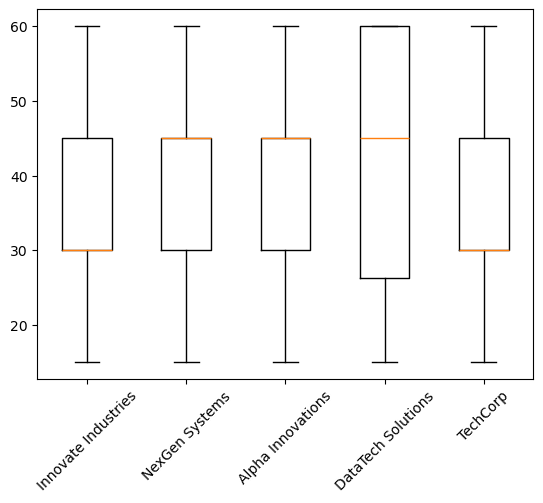

In [ ]:
plt.boxplot(grps,labels=df['Company'].unique())
plt.xticks(rotation=45)
plt.show()

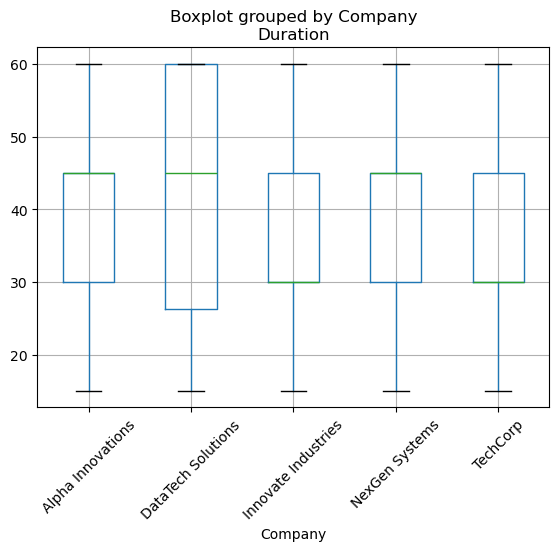

In [ ]:
df.boxplot('Duration',by='Company')
plt.xticks(rotation=45)
plt.show()

### Create pivot tables for ROI by Location and Campaign_Type.

In [ ]:
round(df.pivot_table(index='Location',columns='Campaign_Type',values='ROI',aggfunc='mean'),4)

Campaign_Type,Display,Email,Influencer,Search,Social Media
Location,,,,,
Chicago,4.9757,4.9946,5.0363,5.0306,4.9705
Houston,5.0132,5.0114,4.9966,5.0247,4.9902
Los Angeles,4.9960,5.0060,5.0366,5.0008,5.0152
Miami,5.0558,4.9873,5.0022,5.0085,5.0076
New York,4.9920,4.9723,4.9840,4.9779,4.9751


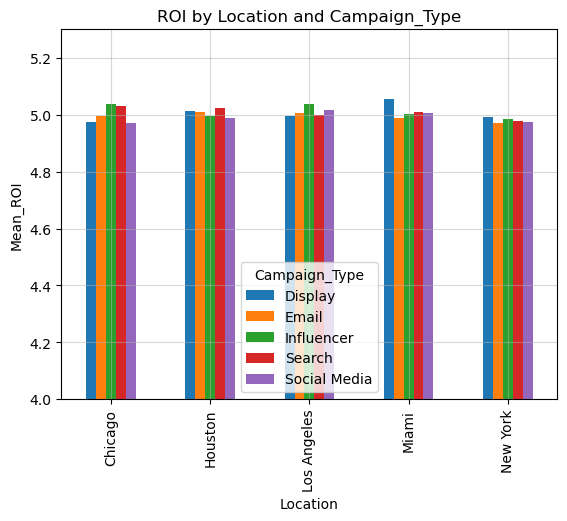

In [ ]:
round(df.pivot_table(index='Location',columns='Campaign_Type',values='ROI',aggfunc='mean'),4).plot(kind='bar',ylim=[4,5.3])
plt.ylabel('Mean_ROI')
plt.title('ROI by Location and Campaign_Type')
plt.grid(alpha=0.5)
plt.show()

### Find rolling average ROI over time.

In [ ]:
rolling_avg=df.groupby('Month')['ROI'].sum().reset_index()
print(rolling_avg.head(5))

   Month       ROI
0      1  85187.94
1      2  76800.53
2      3  84658.06
3      4  82107.47
4      5  85261.47


In [ ]:
rolling_avg['Rolling_avg_ROI']=rolling_avg['ROI'].rolling(window=3).mean()
print(rolling_avg)

    Month       ROI  Rolling_avg_ROI
0       1  85187.94              NaN
1       2  76800.53              NaN
2       3  84658.06     82215.510000
3       4  82107.47     81188.686667
4       5  85261.47     84009.000000
5       6  81956.74     83108.560000
6       7  84651.96     83956.723333
7       8  84902.51     83837.070000
8       9  82677.49     84077.320000
9      10  85219.37     84266.456667
10     11  82188.02     83361.626667
11     12  84876.01     84094.466667


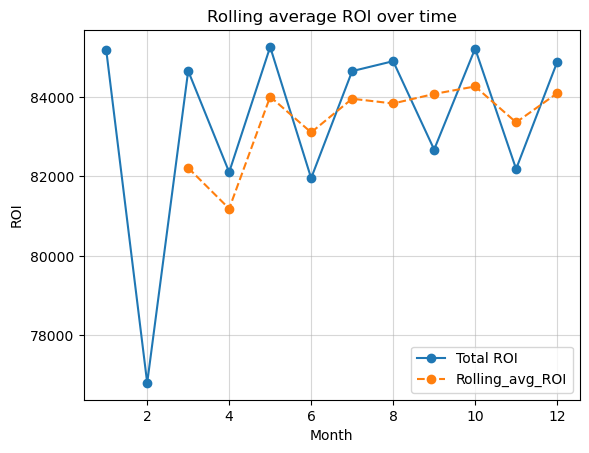

In [ ]:
plt.plot(rolling_avg['Month'],rolling_avg['ROI'],marker='o',label='Total ROI')
plt.plot(rolling_avg['Month'],rolling_avg['Rolling_avg_ROI'],linestyle='--',marker='o',label='Rolling_avg_ROI')
plt.title('Rolling average ROI over time')
plt.xlabel('Month')
plt.ylabel('ROI')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

### Rank companies based on monthly performance.

In [ ]:
monthly_roi=df.groupby(['Company','Month'])['ROI'].mean().reset_index().sort_values(by=['Month','ROI'],ascending=[True,False])

In [ ]:
monthly_roi['Rank']=monthly_roi.groupby('Month')['ROI'].rank(ascending=False,method='dense')

In [ ]:
print(monthly_roi)

                Company  Month       ROI  Rank
36       NexGen Systems      1  5.047622   1.0
12   DataTech Solutions      1  5.037994   2.0
0     Alpha Innovations      1  5.013189   3.0
24  Innovate Industries      1  4.994127   4.0
48             TechCorp      1  4.980294   5.0
13   DataTech Solutions      2  5.048201   1.0
37       NexGen Systems      2  5.046682   2.0
49             TechCorp      2  5.028411   3.0
25  Innovate Industries      2  4.972570   4.0
1     Alpha Innovations      2  4.929058   5.0
14   DataTech Solutions      3  4.997271   1.0
2     Alpha Innovations      3  4.996127   2.0
26  Innovate Industries      3  4.986452   3.0
50             TechCorp      3  4.982179   4.0
38       NexGen Systems      3  4.954962   5.0
51             TechCorp      4  5.016974   1.0
27  Innovate Industries      4  5.004697   2.0
15   DataTech Solutions      4  4.995688   3.0
3     Alpha Innovations      4  4.987488   4.0
39       NexGen Systems      4  4.966796   5.0
4     Alpha I

### Find cumulative Clicks for each company.

In [ ]:
df['cumsum']=df.groupby('Company')['Clicks'].cumsum()

In [ ]:
df.sort_values(by=['Company','cumsum'],ascending=[True,True])

,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,...,Date,Gender,Age_group,Clicks-to-Impressions,CPC,Month,Weekday,roi_category,efficiency,cumsum
2,Alpha Innovations,Influencer,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,...,2021-01-03,Men,25-34,0.075864,17.465753,1,6,High,0.000704,584
8,Alpha Innovations,Social Media,15,Facebook,0.09,18066.0,6.73,Chicago,German,861,...,2021-01-09,Women,35-44,0.490878,20.982578,1,5,High,0.000373,1445
17,Alpha Innovations,Influencer,15,Instagram,0.14,9485.0,4.48,Miami,French,218,...,2021-01-18,Men,18-24,0.023532,43.509174,1,0,Medium,0.000472,1663
18,Alpha Innovations,Social Media,60,Google Ads,0.07,19224.0,6.08,New York,French,182,...,2021-01-19,Men,25-34,0.031390,105.626374,1,1,Medium,0.000316,1845
26,Alpha Innovations,Email,45,Facebook,0.09,9182.0,6.03,Houston,English,953,...,2021-01-27,Women,25-34,0.137796,9.634837,1,2,Medium,0.000657,2798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199984,TechCorp,Email,60,Website,0.08,19503.0,6.50,Chicago,French,981,...,2021-11-26,Men,18-24,0.140464,19.880734,11,4,Medium,0.000333,22163194
199985,TechCorp,Search,30,Website,0.04,18294.0,4.58,Houston,German,964,...,2021-11-27,Women,35-44,0.110323,18.977178,11,5,Medium,0.000250,22164158
199987,TechCorp,Display,60,Website,0.11,17471.0,2.30,New York,German,999,...,2021-11-29,Men,18-24,0.102725,17.488488,11,0,Low,0.000132,22165157
199990,TechCorp,Email,15,Website,0.07,15797.0,6.55,Chicago,Mandarin,470,...,2021-12-02,Men,25-34,0.079298,33.610638,12,3,High,0.000415,22165627


### Identify campaigns contributing to top 20% revenue efficiency.

In [ ]:
df['Revenue']=df['Acquisition_Cost']*(1+df['ROI'])

In [ ]:
dff=df.sort_values(by='Revenue',ascending=False)

In [ ]:
dff['rev_cum']=dff['Revenue'].cumsum()
sum=dff['Revenue'].sum()*0.2
top_20=dff[dff['rev_cum']<=sum]
top_20.head(5)

,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,...,Age_group,Clicks-to-Impressions,CPC,Month,Weekday,roi_category,efficiency,cumsum,Revenue,rev_cum
13018,DataTech Solutions,Influencer,45,Facebook,0.08,19982.0,7.98,Chicago,Spanish,453,...,25-34,0.070715,44.110375,9,2,High,0.000399,1421982,179438.36,179438.36
73094,TechCorp,Influencer,45,Email,0.11,19994.0,7.97,New York,Spanish,318,...,25-34,0.063613,62.874214,4,0,High,0.000399,8118773,179346.18,358784.54
33605,DataTech Solutions,Email,30,Email,0.02,19971.0,7.98,New York,German,540,...,18-24,0.094175,36.983333,1,1,High,0.000400,3663665,179339.58,538124.12
13707,Alpha Innovations,Display,30,Google Ads,0.14,19969.0,7.98,Houston,Spanish,607,...,35-44,0.066681,32.897858,7,3,High,0.000400,1509694,179321.62,717445.74
8280,Alpha Innovations,Social Media,60,YouTube,0.07,19966.0,7.98,Miami,German,642,...,25-34,0.110632,31.099688,9,2,High,0.000400,895473,179294.68,896740.42


### Compare weekday vs weekend engagement.

In [ ]:
weekday_mean=df[df['Weekday'].between(0,4)]['Engagement_Score'].mean()

In [ ]:
weekend_mean=df[df['Weekday'].isin([5,6])]['Engagement_Score'].mean()

In [ ]:
weekday_wise_avg=df[df['Weekday'].between(0,4)].groupby('Weekday')['Engagement_Score'].mean().reset_index()

In [ ]:
weekend_wise_avg=df[df['Weekday'].isin([5,6])].groupby('Weekday')['Engagement_Score'].mean().reset_index()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


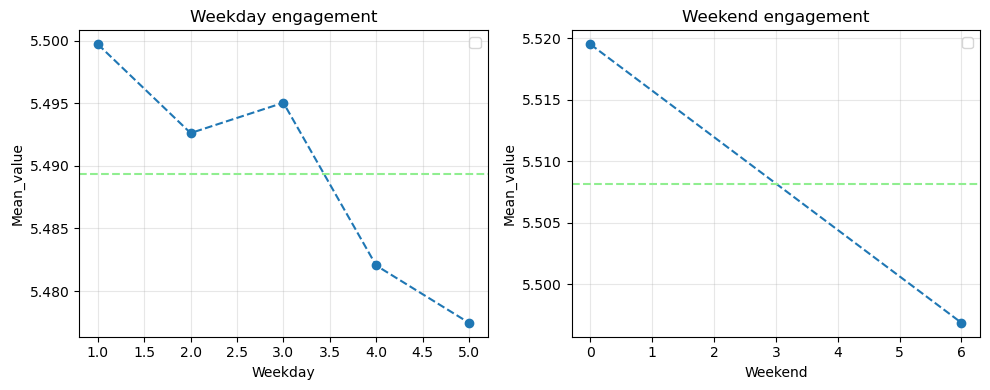

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(10,4))

axes[0].plot(weekday_wise_avg['Weekday'],weekday_wise_avg['Engagement_Score'],linestyle='--',marker='o')
axes[0].axhline(weekday_mean,color='lightgreen',linestyle='--')
axes[0].set_title('Weekday engagement')
axes[0].set_xlabel('Weekday')
axes[0].set_ylabel('Mean_value')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(weekend_wise_avg['Weekday'],weekend_wise_avg['Engagement_Score'],linestyle='--',marker='o')
axes[1].axhline(weekend_mean,color='lightgreen',linestyle='--')
axes[1].set_title('Weekend engagement')
axes[1].set_xlabel('Weekend')
axes[1].set_ylabel('Mean_value')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Find campaigns where CPC is higher than company average.

In [ ]:
 df['Company'].unique()

array(['Innovate Industries', 'NexGen Systems', 'Alpha Innovations',
       'DataTech Solutions', 'TechCorp'], dtype=object)

In [ ]:
for i in df['Company'].unique():
    mean=df[df['Company']==i]['CPC'].mean()
    g=df[df['Company']==i]
    overall=g[g['CPC']>=mean]
    print(overall)


                    Company Campaign_Type  Duration Channel_Used  \
39      Innovate Industries        Search        45   Google Ads   
59      Innovate Industries       Display        15        Email   
80      Innovate Industries    Influencer        60   Google Ads   
82      Innovate Industries    Influencer        60     Facebook   
96      Innovate Industries         Email        15    Instagram   
...                     ...           ...       ...          ...   
199922  Innovate Industries         Email        60   Google Ads   
199924  Innovate Industries       Display        15      Website   
199949  Innovate Industries    Influencer        60     Facebook   
199956  Innovate Industries  Social Media        45      Website   
199998  Innovate Industries    Influencer        30      YouTube   

        Conversion_Rate  Acquisition_Cost   ROI     Location  Language  \
39                 0.08           15495.0  6.97      Chicago    German   
59                 0.05           1

In [ ]:
mean=df[df['Company']=='Innovate Industries']['CPC'].mean()
g=df[df['Company']=='Innovate Industries']
overall=g[g['CPC']>=mean]

### Calculate z-scores for Engagement_Score.

In [ ]:
m=df['Engagement_Score'].mean()
s=df['Engagement_Score'].std()
df['z_score']=(df['Engagement_Score']-m)/s

In [ ]:
df[(df['z_score']>1)|(df['z_score']<-1)]

,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,...,Age_group,Clicks-to-Impressions,CPC,Month,Weekday,roi_category,efficiency,cumsum,Revenue,z_score
2,Alpha Innovations,Influencer,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,...,25-34,0.075864,17.465753,1,6,High,0.000704,584,83436.00,-1.564694
5,DataTech Solutions,Display,15,Instagram,0.07,9716.0,4.36,New York,German,100,...,All,0.060864,97.160000,1,2,Medium,0.000449,317,52077.76,-1.564694
6,NexGen Systems,Email,60,Website,0.13,11067.0,2.86,Los Angeles,Spanish,817,...,35-44,0.093382,13.545900,1,3,Low,0.000258,1312,42718.62,1.568377
10,NexGen Systems,Display,45,Email,0.12,8590.0,3.49,New York,Spanish,321,...,25-34,0.048431,26.760125,1,0,Low,0.000406,1633,38569.10,1.568377
11,Innovate Industries,Influencer,60,Google Ads,0.05,17502.0,3.59,Los Angeles,Mandarin,659,...,25-34,0.073648,26.558422,1,1,Medium,0.000205,1165,80334.18,-1.564694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199983,TechCorp,Influencer,60,Website,0.01,12082.0,7.52,Miami,French,142,...,35-44,0.028253,85.084507,11,3,High,0.000622,22162213,102938.64,1.568377
199987,TechCorp,Display,60,Website,0.11,17471.0,2.30,New York,German,999,...,18-24,0.102725,17.488488,11,0,Low,0.000132,22165157,57654.30,-1.216575
199989,DataTech Solutions,Email,15,Email,0.10,9453.0,5.44,Miami,German,301,...,25-34,0.271906,31.405316,12,2,Medium,0.000575,22038863,60877.32,1.220258
199995,TechCorp,Display,30,Google Ads,0.06,18365.0,2.84,Chicago,German,858,...,All,0.143287,21.404429,12,1,Low,0.000155,22166485,70521.60,-1.564694


### Predict ROI using regression models.

In [ ]:
df.columns

Index(['Company', 'Campaign_Type', 'Duration', 'Channel_Used',
       'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language',
       'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date',
       'Gender', 'Age_group', 'Clicks-to-Impressions', 'CPC', 'Month',
       'Weekday', 'roi_category', 'efficiency', 'cumsum', 'Revenue',
       'z_score'],
      dtype='object')

In [ ]:
df1=df.copy()

In [ ]:
df1.drop(columns=['cumsum','Revenue','z_score','Date'],inplace=True)

In [ ]:
df1=pd.get_dummies(df1)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

In [ ]:
lr=LinearRegression()

x=df1.drop(columns=['ROI'])
y=df1['ROI']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

lr.fit(x_train,y_train)

pred=lr.predict(x_test)
r2=r2_score(y_test,pred)
print('r2_score is:',r2)

r2_score is: 0.8933060328349469


### Predict Conversion_Rate using RandomForestRegressor.

In [ ]:
df1

,Duration,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score,Clicks-to-Impressions,CPC,Month,...,Gender_All,Gender_Men,Gender_Women,Age_group_18-24,Age_group_25-34,Age_group_35-44,Age_group_All,roi_category_High,roi_category_Low,roi_category_Medium
0,30,0.04,16174.0,6.29,506,1922,6,0.263267,31.964427,1,...,False,True,False,True,False,False,False,False,False,True
1,60,0.12,11566.0,5.61,116,7523,7,0.015419,99.706897,1,...,False,False,True,False,False,True,False,False,False,True
2,30,0.07,10200.0,7.18,584,7698,1,0.075864,17.465753,1,...,False,True,False,False,True,False,False,True,False,False
3,60,0.11,12724.0,5.55,217,1820,7,0.119231,58.635945,1,...,True,False,False,False,False,False,True,False,False,True
4,15,0.05,16452.0,6.50,379,4201,3,0.090217,43.408971,1,...,False,True,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,30,0.06,18365.0,2.84,858,5988,1,0.143287,21.404429,12,...,True,False,False,False,False,False,True,False,True,False
199996,15,0.02,8168.0,4.14,228,3068,7,0.074316,35.824561,12,...,False,True,False,False,True,False,False,False,False,True
199997,45,0.05,13397.0,3.25,723,9548,3,0.075723,18.529737,12,...,False,True,False,True,False,False,False,False,True,False
199998,30,0.10,18508.0,3.86,528,2763,1,0.191097,35.053030,12,...,True,False,False,False,False,False,True,False,False,True


from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=100)

x=df1.drop(columns=['Conversion_Rate'])
y=df1['Conversion_Rate']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

rf.fit(x_train,y_train)
pred_rf=rf.predict(x_test)
r2_rf=r2_score(y_test,pred_rf)

print(r2_rf)


### Apply PCA on numerical features.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
pca=PCA(n_components=None)

In [ ]:
x=df.drop(columns=['ROI','Date'])
y=df['ROI']

In [ ]:
le=LabelEncoder()
for i in x.select_dtypes(include='object'):
    x[i]=le.fit_transform(x[i])

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
ss=StandardScaler()

In [ ]:
x_train_tranformed=ss.fit_transform(x_train)
x_test_transformed=ss.transform(x_test)

In [ ]:
lr.fit(x_train,y_train)
pred=lr.predict(x_test)
print(r2_score(y_test,pred))

0.8941587278983402


In [ ]:
pca_x_train=pca.fit_transform(x_train_tranformed)
pca_x_test=pca.transform(x_test_transformed)

In [ ]:
lr.fit(pca_x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
pred_pca=lr.predict(pca_x_test)

In [ ]:
r2_score(y_test,pred_pca)

0.9699049577926037

In [ ]:
s=list(pca.explained_variance_ratio_.cumsum())

In [ ]:
pd.Series(s)

0     0.109971
1     0.197017
2     0.281846
3     0.341296
4     0.396340
5     0.451113
6     0.495276
7     0.539119
8     0.582835
9     0.626517
10    0.670173
11    0.713749
12    0.757182
13    0.800459
14    0.843615
15    0.886598
16    0.929331
17    0.956848
18    0.981015
19    0.991025
20    0.997246
21    1.000000
22    1.000000
dtype: float64

### Cluster campaigns using KMeans.

In [ ]:
from sklearn.cluster import KMeans

In [ ]:

x=df.drop(columns=['Date','efficiency'])
y=df['efficiency']

In [ ]:
x=pd.get_dummies(x)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
ss=MinMaxScaler()

In [ ]:
x=ss.fit_transform(x)

In [ ]:
wacc=[]
for i in range(1,12):
    km=KMeans(n_clusters=i)
    km.fit_predict(x)
    wacc.append(km.inertia_)
print(wacc)


/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


[1590262.3809263392, 1508456.3465549718, 1438378.7833119573, 1373897.427419782, 1337573.1387175648, 1303136.4641503934, 1301486.8476999055, 1267120.4893854414, 1255734.0049691917, 1251452.018520268, 1216165.71758536]


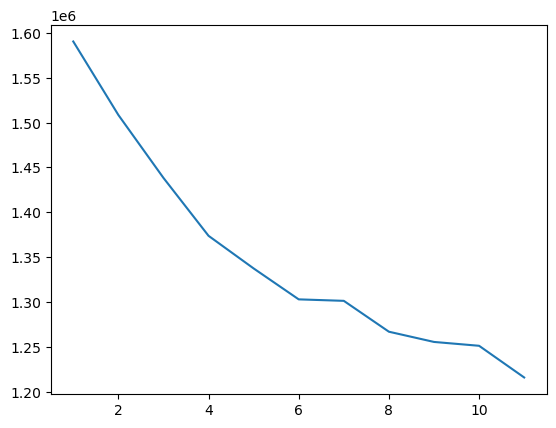

In [ ]:
plt.plot([i for i in range(1,12)],wacc)

In [ ]:
km=KMeans(n_clusters=4)
cluster=km.fit_predict(x)

In [ ]:
df['cluster']=cluster

In [ ]:
x

array([[0.33333333, 0.21428571, 0.74493333, ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.78571429, 0.43773333, ..., 0.        , 0.        ,
        1.        ],
       [0.33333333, 0.42857143, 0.34666667, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.66666667, 0.28571429, 0.5598    , ..., 0.        , 1.        ,
        0.        ],
       [0.33333333, 0.64285714, 0.90053333, ..., 0.        , 0.        ,
        1.        ],
       [0.66666667, 0.        , 0.589     , ..., 1.        , 0.        ,
        0.        ]], shape=(200000, 55))

In [ ]:
from sklearn.metrics import silhouette_score
idx = np.random.choice(x.shape[0], 2000, replace=False)
score = silhouette_score(x[idx], cluster[idx])
print("Silhouette Score (sampled):", score)

Silhouette Score (sampled): 0.0779809102417629


### Outlier finding using IsolationForest

In [ ]:
from sklearn.ensemble import IsolationForest

rng = np.random.RandomState(42)
X = 0.3 * rng.randn(100, 2)
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X + 2, X - 2, X_outliers]  # combine normal + outliers

In [ ]:
clf = IsolationForest(contamination=0.1, random_state=42)
clf.fit(df[['CPC']])

,n_estimators,100
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [ ]:
anomalies=clf.predict(df[['CPC']])

In [ ]:
df[anomalies<0]

,Company,Campaign_Type,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,...,Clicks-to-Impressions,CPC,Month,Weekday,roi_category,efficiency,cumsum,Revenue,z_score,cluster
1,NexGen Systems,Email,60,Google Ads,0.12,11566.0,5.61,New York,German,116,...,0.015419,99.706897,1,5,Medium,0.000485,116,76451.26,0.524020,1
5,DataTech Solutions,Display,15,Instagram,0.07,9716.0,4.36,New York,German,100,...,0.060864,97.160000,1,2,Medium,0.000449,317,52077.76,-1.564694,3
16,Innovate Industries,Display,45,Website,0.08,5478.0,4.53,Houston,English,931,...,0.374196,5.883996,1,6,Medium,0.000827,2395,30293.34,-0.868456,1
18,Alpha Innovations,Social Media,60,Google Ads,0.07,19224.0,6.08,New York,French,182,...,0.031390,105.626374,1,1,Medium,0.000316,1845,136105.92,-1.564694,0
40,DataTech Solutions,Social Media,30,Website,0.04,18684.0,4.57,New York,French,212,...,0.044934,88.132075,2,2,Medium,0.000245,3143,104069.88,-0.520337,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199932,NexGen Systems,Influencer,45,YouTube,0.06,11352.0,2.04,Chicago,French,120,...,0.018724,94.600000,10,1,Low,0.000180,21951289,34510.08,-0.520337,1
199946,TechCorp,Influencer,60,Instagram,0.09,17913.0,4.60,Miami,Mandarin,115,...,0.081502,155.765217,10,1,Medium,0.000257,22159051,100312.80,0.872139,1
199965,NexGen Systems,Social Media,15,YouTube,0.08,18098.0,3.09,Chicago,German,247,...,0.082942,73.271255,11,6,Low,0.000171,21955096,74020.82,-0.520337,3
199970,Alpha Innovations,Search,60,Facebook,0.03,13824.0,3.89,Chicago,Mandarin,137,...,0.048189,100.905109,11,4,Medium,0.000281,21979906,67599.36,1.568377,3


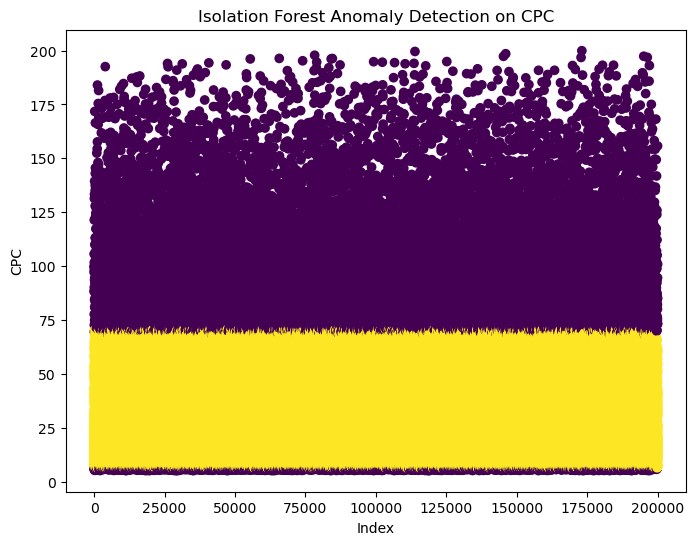

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df.index, df['CPC'], c=anomalies)
plt.title("Isolation Forest Anomaly Detection on CPC")
plt.xlabel("Index")
plt.ylabel("CPC")
plt.show()